# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Capstone Project

### Objectives
- Analyze NAV trends
- Study AUM growth
- Analyze SIP inflows
- Understand investor demographics
- Examine geographic distribution
- Study folio growth
- Analyze portfolio sector allocation
- Generate business insights

# 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 2. Load Datasets

In [4]:
# Load datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

category_inflow = pd.read_csv("../data/raw/05_category_inflows.csv")

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

investors = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav,
    "AUM": aum,
    "SIP": sip,
    "Category Inflow": category_inflow,
    "Folio": folio,
    "Performance": performance,
    "Investors": investors,
    "Portfolio": portfolio,
    "Benchmark": benchmark
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category Inflow: (144, 3)
Folio: (21, 6)
Performance: (40, 19)
Investors: (32778, 13)
Portfolio: (322, 8)
Benchmark: (8050, 3)


In [6]:
for name, df in datasets.items():
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(df.columns.tolist())


Fund Master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV History
['amfi_code', 'date', 'nav']

AUM
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category Inflow
['month', 'category', 'net_inflow_crore']

Folio
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

Inv

In [3]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\PRATEEK\Downloads\MutualFundAnalytics\notebooks


# 3. Dataset overview

In [7]:
for name, df in datasets.items():
    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nData Types:")
    print(df.dtypes)


Fund Master

Shape:
(40, 15)

Missing Values:
amfi_code             0
fund_house            0
scheme_name           0
category              0
sub_category          0
plan                  0
launch_date           0
benchmark             0
expense_ratio_pct     0
exit_load_pct         0
min_sip_amount        0
min_lumpsum_amount    0
fund_manager          0
risk_category         0
sebi_category_code    0
dtype: int64

Data Types:
amfi_code               int64
fund_house             object
scheme_name            object
category               object
sub_category           object
plan                   object
launch_date            object
benchmark              object
expense_ratio_pct     float64
exit_load_pct         float64
min_sip_amount          int64
min_lumpsum_amount      int64
fund_manager           object
risk_category          object
sebi_category_code     object
dtype: object

NAV History

Shape:
(46000, 3)

Missing Values:
amfi_code    0
date         0
nav          0
dtype: in

# 4. NAV Trend Analysis

In [8]:
nav_merged = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_merged.head()

,amfi_code,date,nav,scheme_name
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth


In [9]:
import plotly.express as px

fig = px.line(
    nav_merged,
    x='date',
    y='nav',
    color='scheme_name',
    title='Daily NAV Trend of Mutual Fund Schemes'
)

fig.update_layout(
    height=700,
    legend_title='Scheme'
)

fig.show()

### Insight

NAV values generally show an upward trend over time.

Most equity-oriented schemes exhibit strong growth during bullish market phases.

# 5. AUM Growth Analysis

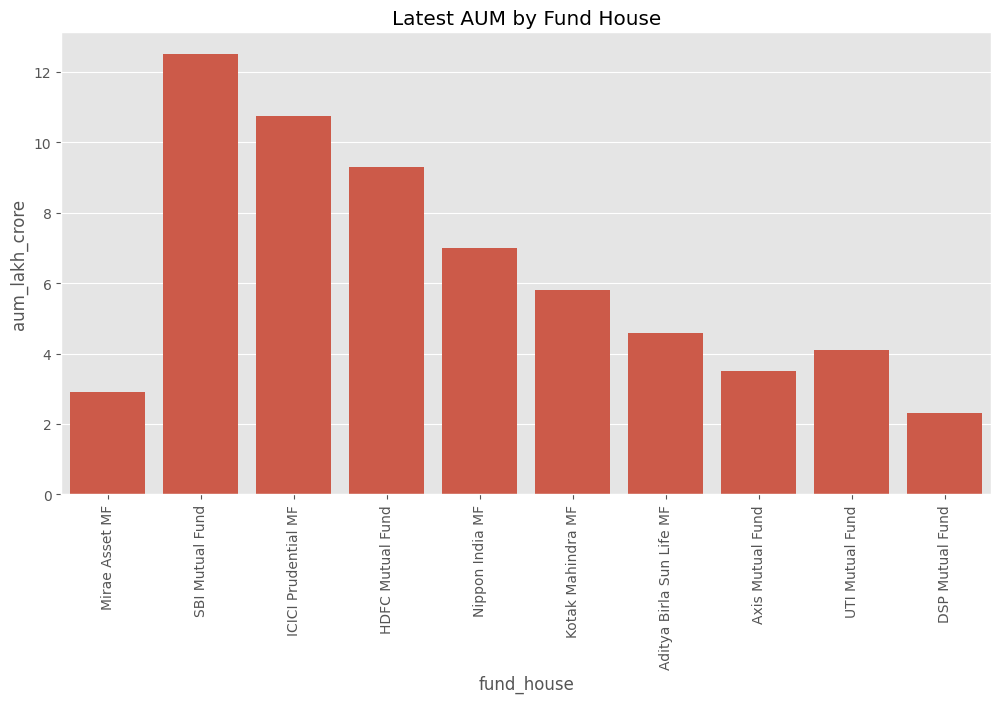

In [36]:
plt.figure(figsize=(12,6))

latest_aum = aum.sort_values('date').groupby(
    'fund_house'
).tail(1)

sns.barplot(
    data=latest_aum,
    x='fund_house',
    y='aum_lakh_crore'
)

plt.xticks(rotation=90)

plt.title('Latest AUM by Fund House')

plt.savefig(
    "../reports/charts/fund_house.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
latest_aum.sort_values(
    'aum_lakh_crore',
    ascending=False
).head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


# 6. SIP Inflow Analysis

In [12]:
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(
    sip,
    x='month',
    y='sip_inflow_crore',
    markers=True,
    title='Monthly SIP Inflow Trend'
)

fig.show()

In [13]:
sip.loc[
    sip['sip_inflow_crore'].idxmax()
]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

# 7. Category Inflow Heatmap

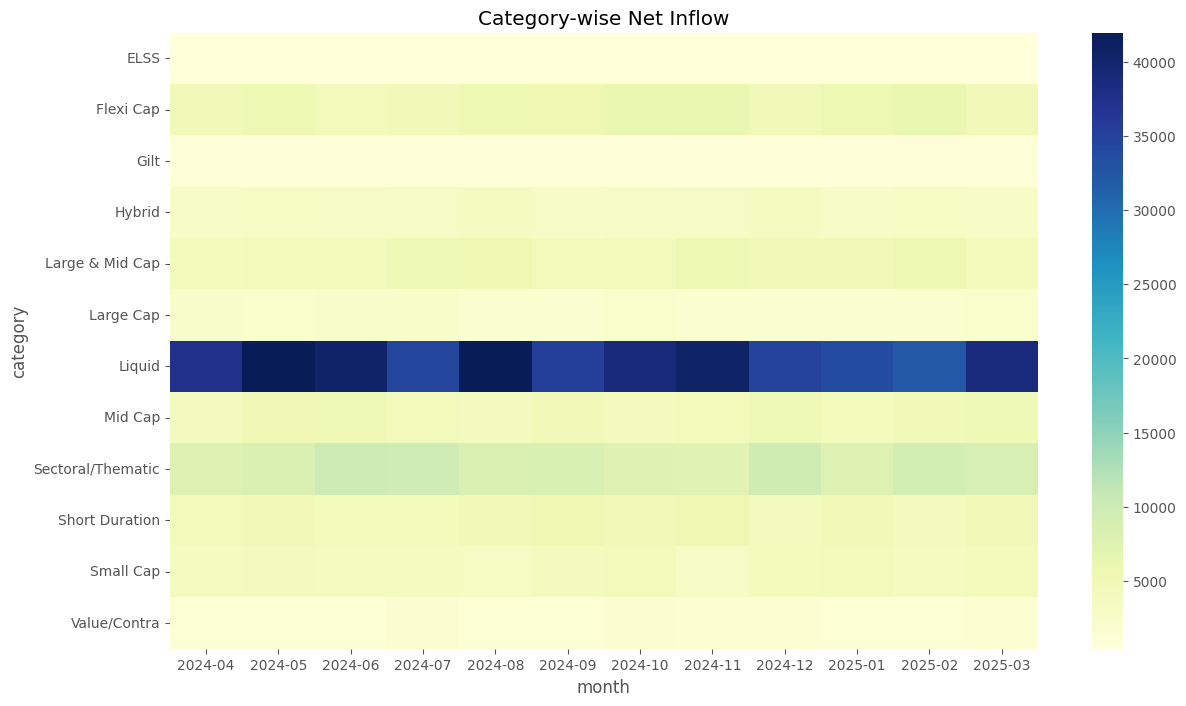

In [37]:
heatmap_data = category_inflow.pivot(
    index='category',
    columns='month',
    values='net_inflow_crore'
)

plt.figure(figsize=(14,8))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Category-wise Net Inflow')

plt.savefig(
    "../reports/charts/Catrgory-wise_net_inflow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 8. Investor Demographics Analysis

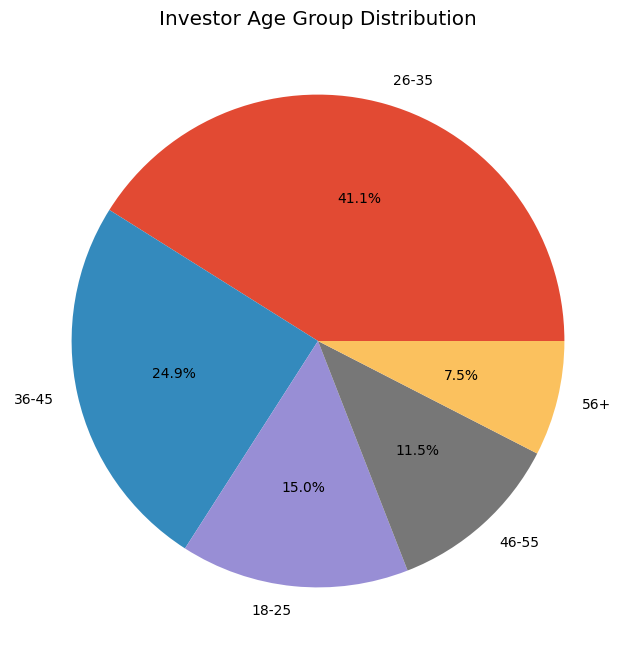

In [38]:
plt.figure(figsize=(8,8))

investors['age_group'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Investor Age Group Distribution')

plt.savefig(
    "../reports/charts/investor_age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The majority of investors belong to the dominant age segment, indicating the primary customer base for mutual fund investments.

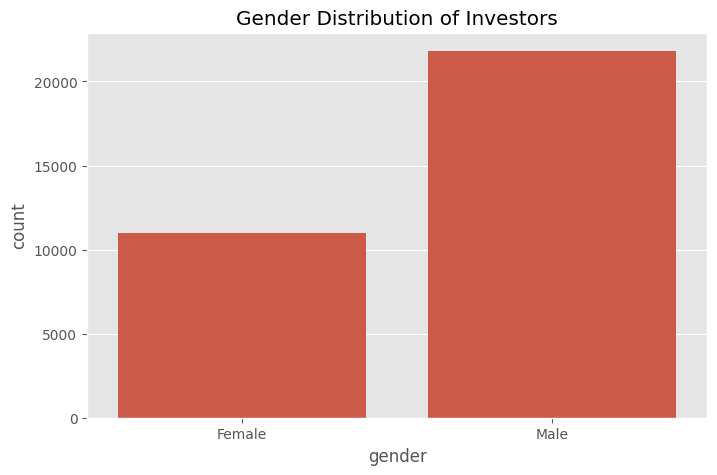

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=investors,
    x='gender'
)

plt.title('Gender Distribution of Investors')

plt.savefig(
    "../reports/charts/Gender_distribution_of_investors.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

The investor base shows a measurable gender distribution which can be used for targeted marketing and customer acquisition strategies.

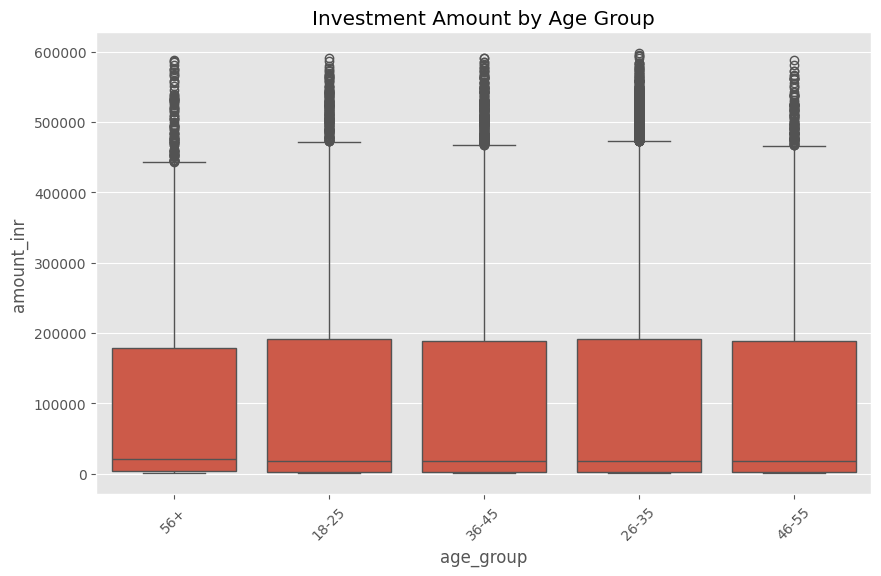

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investors,
    x='age_group',
    y='amount_inr'
)

plt.title('Investment Amount by Age Group')

plt.xticks(rotation=45)

plt.savefig(
    "../reports/charts/investment_amount_by_age_grp.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

Investment behavior varies across age groups, with certain segments exhibiting larger transaction values and higher variability.

# 9. Geographic Distribution Analysis

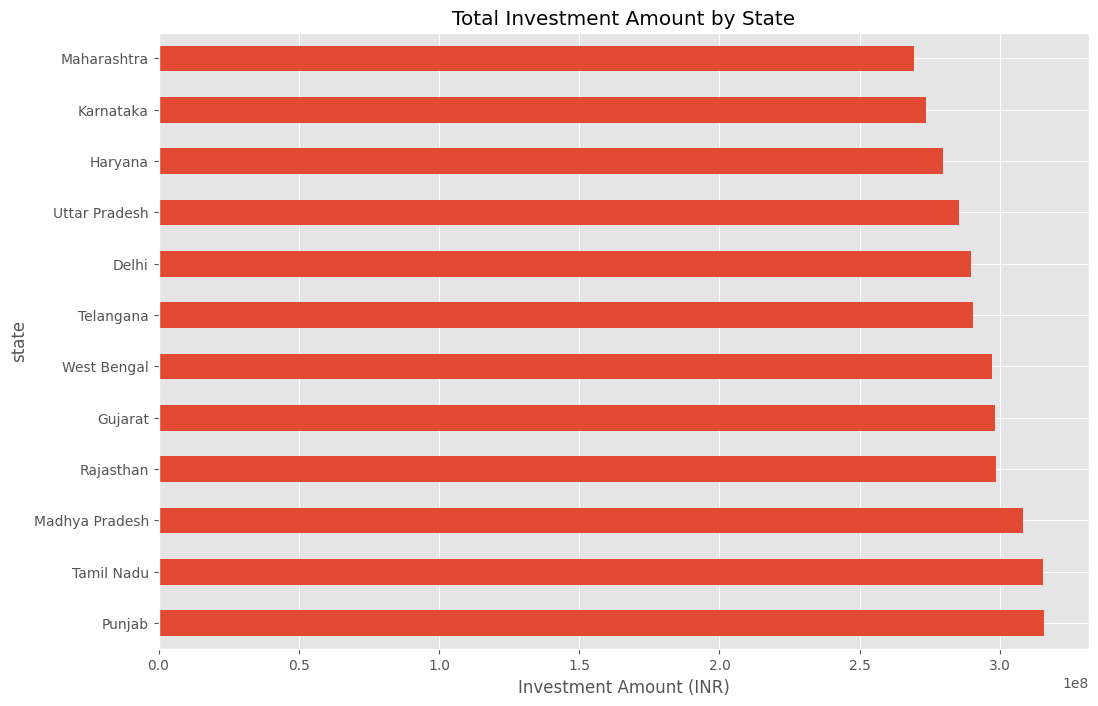

In [41]:
state_amount = (
    investors
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

state_amount.plot(kind='barh')

plt.title('Total Investment Amount by State')

plt.xlabel('Investment Amount (INR)')

plt.savefig(
    "../reports/charts/Total_investment_amount_by_state.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

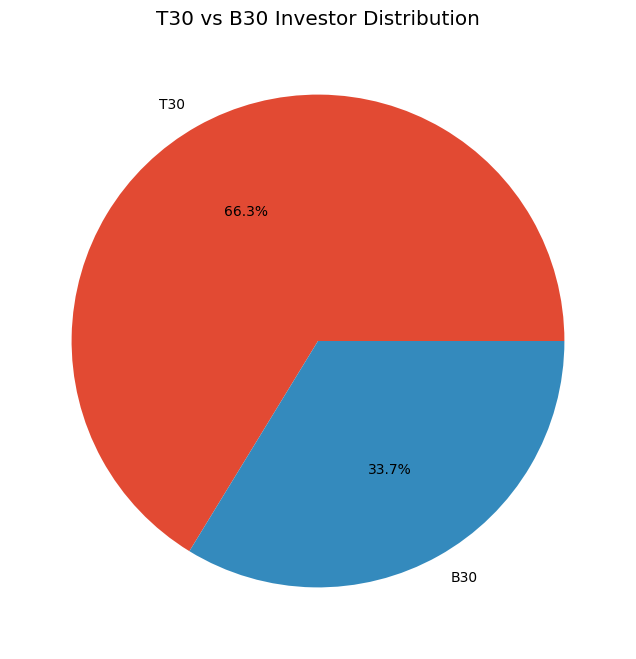

In [42]:
plt.figure(figsize=(8,8))

investors['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title('T30 vs B30 Investor Distribution')

plt.savefig(
    "../reports/charts/investor_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 10. Folio Growth Analysis

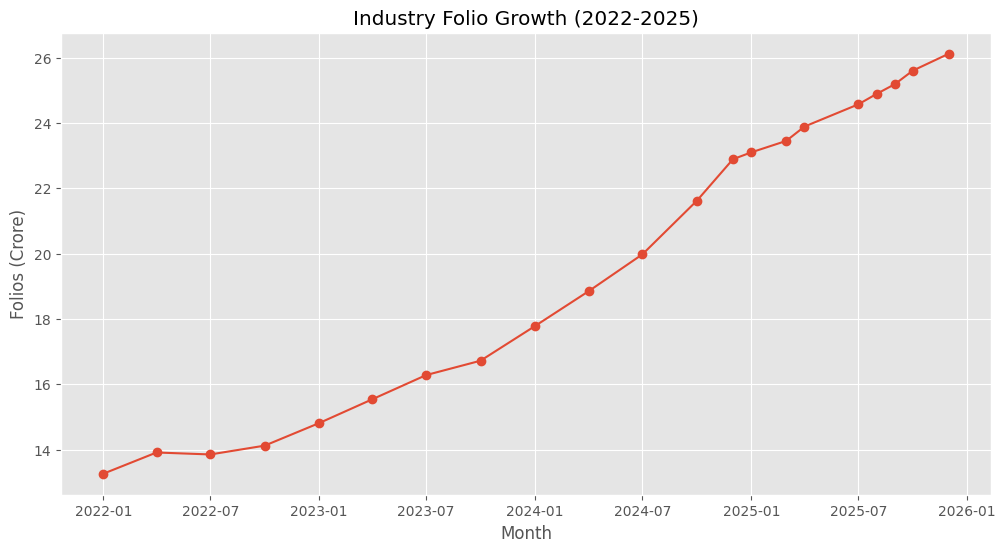

In [43]:
# Convert month column to datetime

folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

plt.title('Industry Folio Growth (2022-2025)')
plt.xlabel('Month')
plt.ylabel('Folios (Crore)')
plt.grid(True)

plt.savefig(
    "../reports/charts/industry_folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

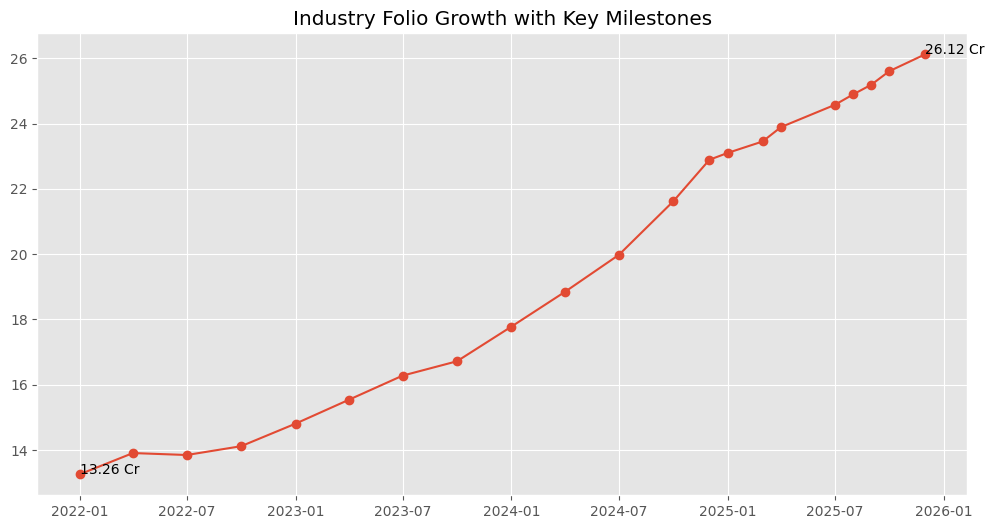

In [44]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore'],
    marker='o'
)

# Start point
plt.annotate(
    f"{folio.iloc[0]['total_folios_crore']} Cr",
    (
        folio.iloc[0]['month'],
        folio.iloc[0]['total_folios_crore']
    )
)

# End point
plt.annotate(
    f"{folio.iloc[-1]['total_folios_crore']} Cr",
    (
        folio.iloc[-1]['month'],
        folio.iloc[-1]['total_folios_crore']
    )
)

plt.title('Industry Folio Growth with Key Milestones')

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

The mutual fund industry witnessed strong folio growth over the period, indicating increasing retail participation and wider adoption of SIP-based investing.

# 11. Portfolio Sector Allocation

In [26]:
sector_weights = (
    portfolio
    .groupby('sector')['weight_pct']
    .sum()
    .sort_values(ascending=False)
)

sector_weights.head()

sector
Banking       652.26
IT            455.47
Pharma        407.45
Automobile    323.65
Utilities     265.54
Name: weight_pct, dtype: float64

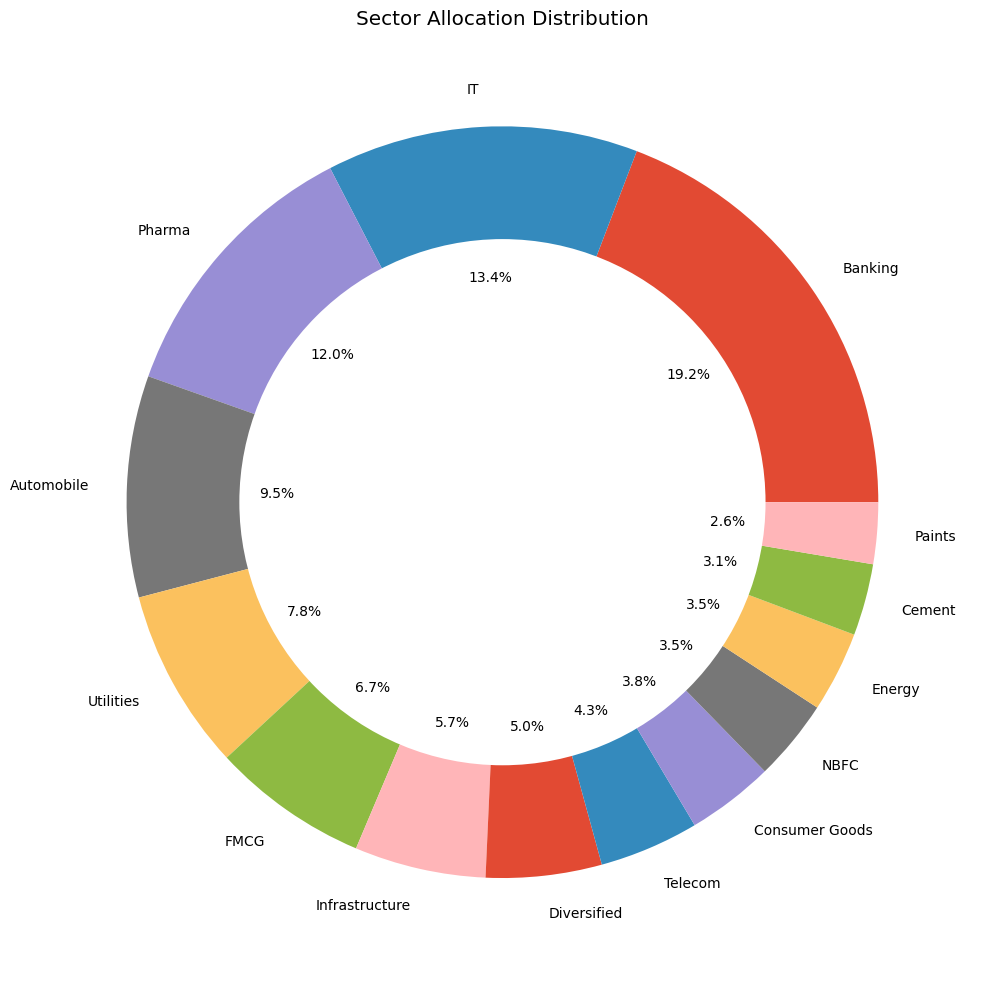

In [45]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Sector Allocation Distribution')

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight

The portfolio is concentrated in a few dominant sectors, highlighting sector preferences among equity mutual funds. Sector diversification helps manage portfolio risk while maintaining growth potential.

# 12 . NAV Correlation Matrix

In [28]:
nav_corr = nav.merge(
    fund_master[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

nav_corr['date'] = pd.to_datetime(
    nav_corr['date']
)

In [29]:
pivot_nav = nav_corr.pivot(
    index='date',
    columns='scheme_name',
    values='nav'
)

daily_returns = pivot_nav.pct_change()

In [30]:
selected_funds = daily_returns.columns[:10]

corr_matrix = daily_returns[
    selected_funds
].corr()

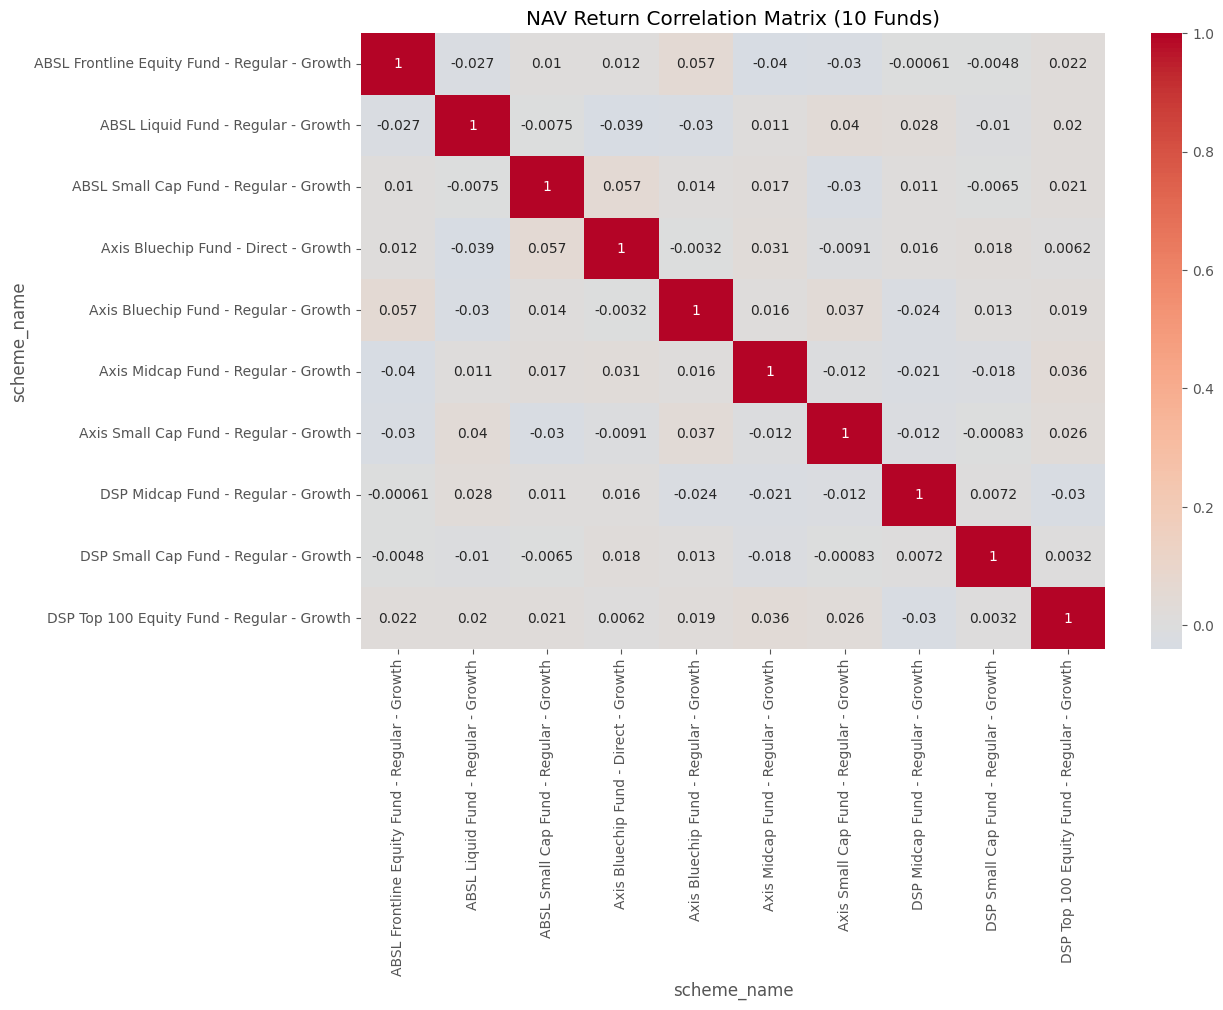

In [46]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title(
    'NAV Return Correlation Matrix (10 Funds)'
)
plt.savefig(
    "../reports/charts/nav_return_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Insight

Funds belonging to similar investment categories generally exhibit higher correlations, while diversified categories demonstrate lower co-movement.

# 13 . Benchmark Index Trend Analysis

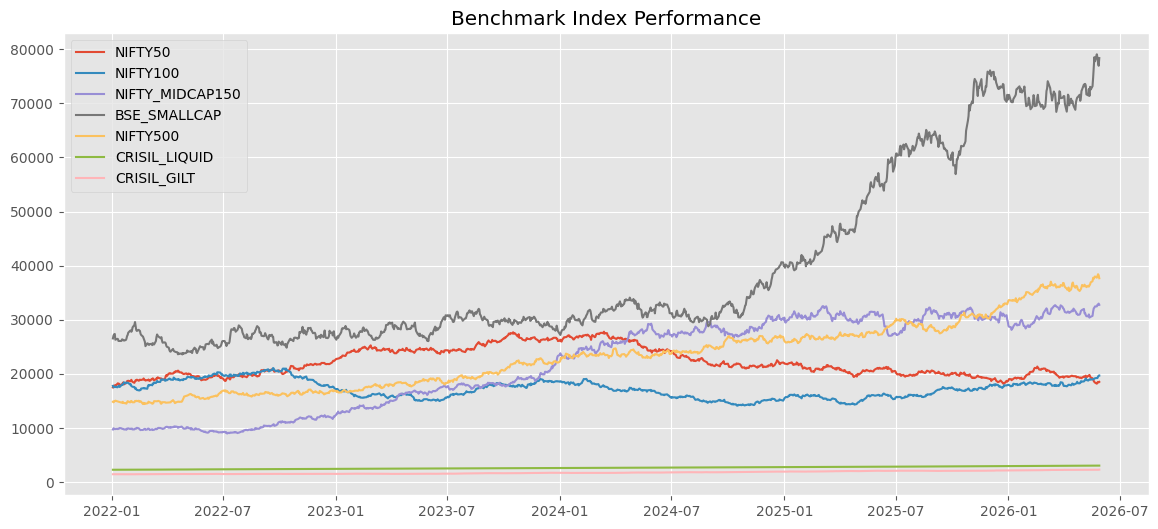

In [47]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

plt.figure(figsize=(14,6))

for index_name in benchmark['index_name'].unique():

    subset = benchmark[
        benchmark['index_name'] == index_name
    ]

    plt.plot(
        subset['date'],
        subset['close_value'],
        label=index_name
    )

plt.title('Benchmark Index Performance')

plt.legend()
plt.savefig(
    "../reports/charts/benchmark_index_performance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [33]:
import os

os.listdir("../reports")

['charts', 'data_quality_summary.txt']

### Insight

Benchmark indices generally show long-term growth despite periodic market corrections, reflecting broader market expansion.

# 14. Key Findings

## Summary of Exploratory Data Analysis

### 1. NAV Performance Trends
- Most mutual fund schemes exhibited a long-term upward NAV trajectory during the analysis period.
- NAV growth accelerated during bullish market phases, reflecting positive market sentiment and wealth creation for investors.
- Temporary declines and corrections were observed during periods of market volatility.

### 2. Asset Under Management (AUM)
- AUM remains concentrated among a few leading fund houses, indicating strong investor trust in established asset management companies.
- Larger fund houses manage significantly higher assets compared to smaller competitors, highlighting market dominance.

### 3. SIP Inflow Growth
- Monthly SIP inflows demonstrated a consistent upward trend over the years.
- Increasing SIP contributions indicate growing retail participation and long-term investment discipline among investors.
- Record-high SIP inflows reflect rising awareness and adoption of mutual fund investing.

### 4. Category-wise Investment Patterns
- Certain mutual fund categories consistently attracted higher net inflows than others.
- Equity-oriented categories generally received stronger investor interest compared to conservative investment categories.
- Inflow patterns varied across market conditions and investment themes.

### 5. Investor Demographics
- A significant proportion of investors belong to a limited number of age groups, indicating concentrated participation among specific demographic segments.
- Investment amounts vary across age groups, suggesting differences in risk appetite, income levels, and financial goals.
- Gender distribution highlights opportunities for targeted investor outreach and inclusion initiatives.

### 6. Geographic Distribution
- Investment activity is concentrated in a few major states and urban regions.
- T30 cities continue to contribute a substantial share of investments, while B30 cities demonstrate growing participation.
- Geographic diversification of investors presents opportunities for further mutual fund penetration.

### 7. Folio Growth
- Industry folio counts increased steadily throughout the analysis period.
- Growth in folios reflects expanding retail investor participation and increasing confidence in mutual fund products.
- Rising folio numbers indicate continued industry expansion and financial inclusion.

### 8. Portfolio Sector Allocation
- Mutual fund portfolios show concentration in key sectors of the economy.
- Sector allocation patterns indicate preference toward sectors with strong growth potential.
- Diversification across sectors helps reduce concentration risk and improve portfolio stability.

### 9. Benchmark Performance
- Benchmark indices displayed long-term growth despite periodic market corrections.
- Mutual fund performance trends generally align with broader market movements represented by benchmark indices.
- Sustained benchmark growth reflects overall market expansion during the study period.

### 10. Fund Correlation Analysis
- Funds within similar investment categories exhibit higher return correlations.
- Diversified categories demonstrate relatively lower correlation, offering diversification benefits.
- Correlation analysis helps investors understand portfolio diversification opportunities and risk exposure.

## Overall Conclusion

The analysis indicates robust growth in the mutual fund industry, driven by increasing SIP participation, rising folio counts, expanding AUM, and strong investor engagement. Long-term market growth, coupled with diversified investment opportunities across sectors and categories, continues to support the expansion of mutual fund investments in India.

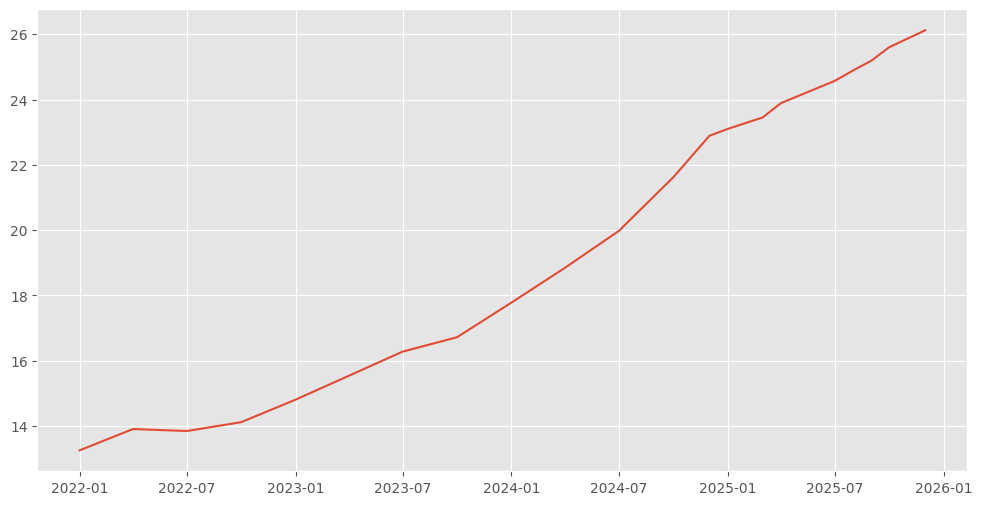

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    folio['month'],
    folio['total_folios_crore']
)

plt.savefig(
    "../reports/charts/folio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()